--- SUMMARY STATISTICS ---
       Annual_Rainfall  Cloud_Visibility  Seasonal_Rainfall  Avg_Temperature  \
count     1.117957e+06      1.117957e+06       1.117957e+06     1.117957e+06   
mean      4.926671e+00      4.946893e+00       4.921450e+00     4.934093e+00   
std       2.093879e+00      2.072333e+00       2.056387e+00     2.057742e+00   
min       0.000000e+00      0.000000e+00       0.000000e+00     0.000000e+00   
25%       3.000000e+00      4.000000e+00       3.000000e+00     3.000000e+00   
50%       5.000000e+00      5.000000e+00       5.000000e+00     5.000000e+00   
75%       6.000000e+00      6.000000e+00       6.000000e+00     6.000000e+00   
max       1.800000e+01      1.700000e+01       1.600000e+01     1.700000e+01   

           Humidity  Catchment_Area   River_Level    Flood_Risk  
count  1.117957e+06    1.117957e+06  1.117957e+06  1.117957e+06  
mean   4.953999e+00    4.942619e+00  4.927791e+00  5.455299e-01  
std    2.088899e+00    2.068545e+00  2.065992e+00  4.9

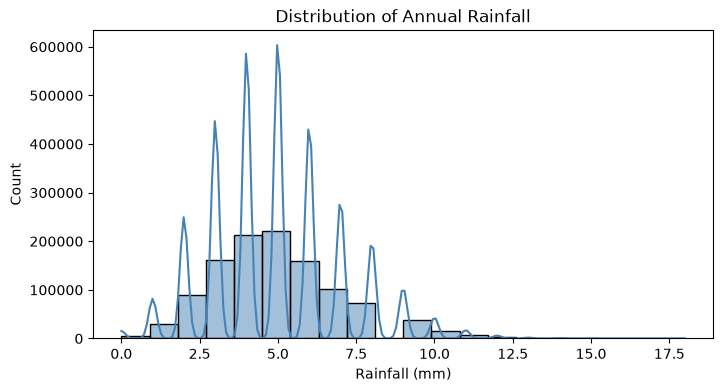

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('data/Flood_prediction.csv')


column_mapping = {
    'TopographyDrainage': 'Annual_Rainfall',
    'DrainageSystems': 'Cloud_Visibility',
    'MonsoonIntensity': 'Seasonal_Rainfall',
    'ClimateChange': 'Avg_Temperature',
    'CoastalVulnerability': 'Humidity',
    'AgriculturalPractices': 'Catchment_Area',
    'Siltation': 'River_Level'
}
df = df.rename(columns=column_mapping)


df['Flood_Risk'] = (df['FloodProbability'] >= 0.5).astype(int)


expected_columns = [
    'Annual_Rainfall', 'Cloud_Visibility', 'Seasonal_Rainfall', 
    'Avg_Temperature', 'Humidity', 'Catchment_Area', 'River_Level', 'Flood_Risk'
]
df_final = df[expected_columns]


print("--- SUMMARY STATISTICS ---")
print(df_final.describe())


plt.figure(figsize=(8, 4))
sns.histplot(df_final['Annual_Rainfall'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Annual Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Count')
plt.show()


C:\Users\kolli\AppData\Local\Temp\ipykernel_7884\2220438078.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flood_counts.index, y=flood_counts.values, palette='Set2')


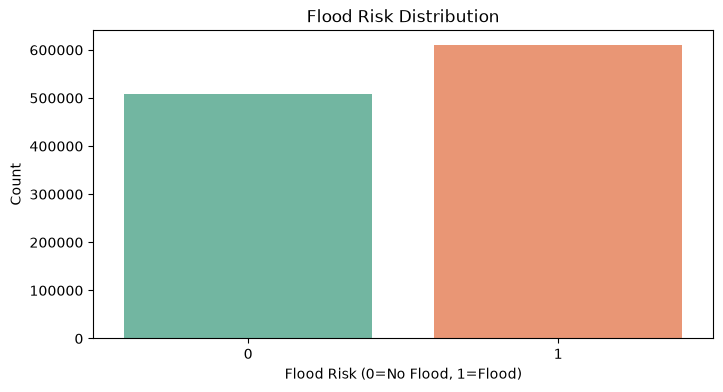

In [17]:
plt.figure(figsize=(8, 4))
flood_counts = df['Flood_Risk'].value_counts()
sns.barplot(x=flood_counts.index, y=flood_counts.values, palette='Set2')
plt.title('Flood Risk Distribution')
plt.xlabel('Flood Risk (0=No Flood, 1=Flood)')
plt.ylabel('Count')
plt.show()
